In [59]:
import pandas as pd 
import numpy as np

In [60]:
df = pd.read_csv(r'data\titanic_limpio.csv')

In [61]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin Datos,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1


### Porcentaje de supervivientes

In [62]:
porcentaje_sobrevivientes = (df['Survived'].mean()) * 100
print(f"Porcentaje de sobrevivientes: {porcentaje_sobrevivientes:.2f}%")

Porcentaje de sobrevivientes: 38.38%


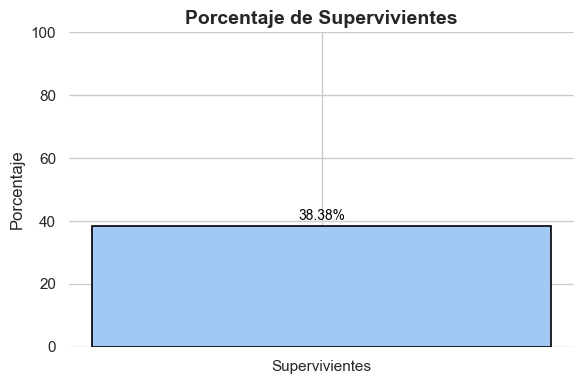

In [63]:
import seaborn as sns


sns.set_theme(style="whitegrid")


fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Supervivientes'], [porcentaje_sobrevivientes], color=sns.color_palette("pastel")[0], edgecolor='black', linewidth=1.2)


ax.set_ylabel('Porcentaje', fontsize=12)
ax.set_title('Porcentaje de Supervivientes', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)


for i, v in enumerate([porcentaje_sobrevivientes]):
    ax.text(i, v + 2, f"{v:.2f}%", ha='center', fontsize=10, color='black')


sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()


### los apellido más repetidos por clase

In [64]:
# Extraer apellidos
df['LastName'] = df['Name'].str.split(',').str[0]

# Contar apellidos más repetidos por clase
apellidos_por_clase = df.groupby('Pclass')['LastName'].value_counts().groupby(level=0).head(3)
print(apellidos_por_clase)

Pclass  LastName 
1       Carter       4
        Fortune      4
        Allison      3
2       Brown        3
        Collyer      3
        Hart         3
3       Andersson    9
        Sage         7
        Goodwin      6
Name: count, dtype: int64


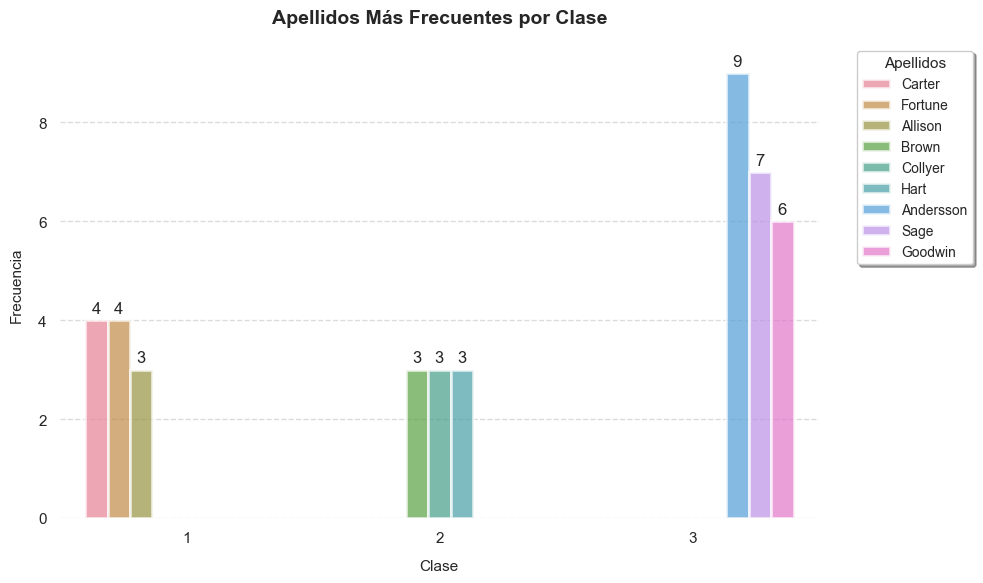

In [65]:
# Crear el gráfico con seaborn
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))

# Crear el gráfico de barras con colores modernos
plot = sns.barplot(
    data=apellidos_por_clase.unstack().reset_index().melt(id_vars='Pclass', var_name='Apellido', value_name='Frecuencia'),
    x='Pclass', y='Frecuencia', hue='Apellido',
    palette="husl",  # Paleta de colores moderna
    alpha=0.7,  # Transparencia para suavizar
    edgecolor='white',
    linewidth=2,
    ax=ax
)

# Añadir valores sobre las barras
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f')

# Estilizar el gráfico
ax.set_ylabel('Frecuencia', fontsize=11, labelpad=10)
ax.set_xlabel('Clase', fontsize=11, labelpad=10)
ax.set_title('Apellidos Más Frecuentes por Clase', fontsize=14, pad=20, fontweight='bold')

# Personalizar la leyenda
ax.legend(
    title='Apellidos',
    title_fontsize=11,
    fontsize=10,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=True,
    fancybox=True,
    shadow=True
)

# Personalizar grid y ejes
ax.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(left=True, bottom=True)

# Ajustar márgenes
plt.tight_layout()
plt.show()


### Precio medio por clase

In [66]:
#calcular precio promedio de pasaje por clase
precio_promedio_por_clase = df.groupby('Pclass')['Fare'].mean()

In [67]:
precio_promedio_por_clase

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

### edad por clase

In [68]:
#edad promedio por clase
edad_promedio_por_clase = df.groupby('Pclass')['Age'].mean()

In [69]:
edad_promedio_por_clase

Pclass
1    36.812130
2    29.765380
3    25.932627
Name: Age, dtype: float64

### supervivientes por rangos de edad

C:\Users\Andrei.Baidurov\AppData\Local\Temp\ipykernel_10328\1853668665.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=stats_por_edad.reset_index(),


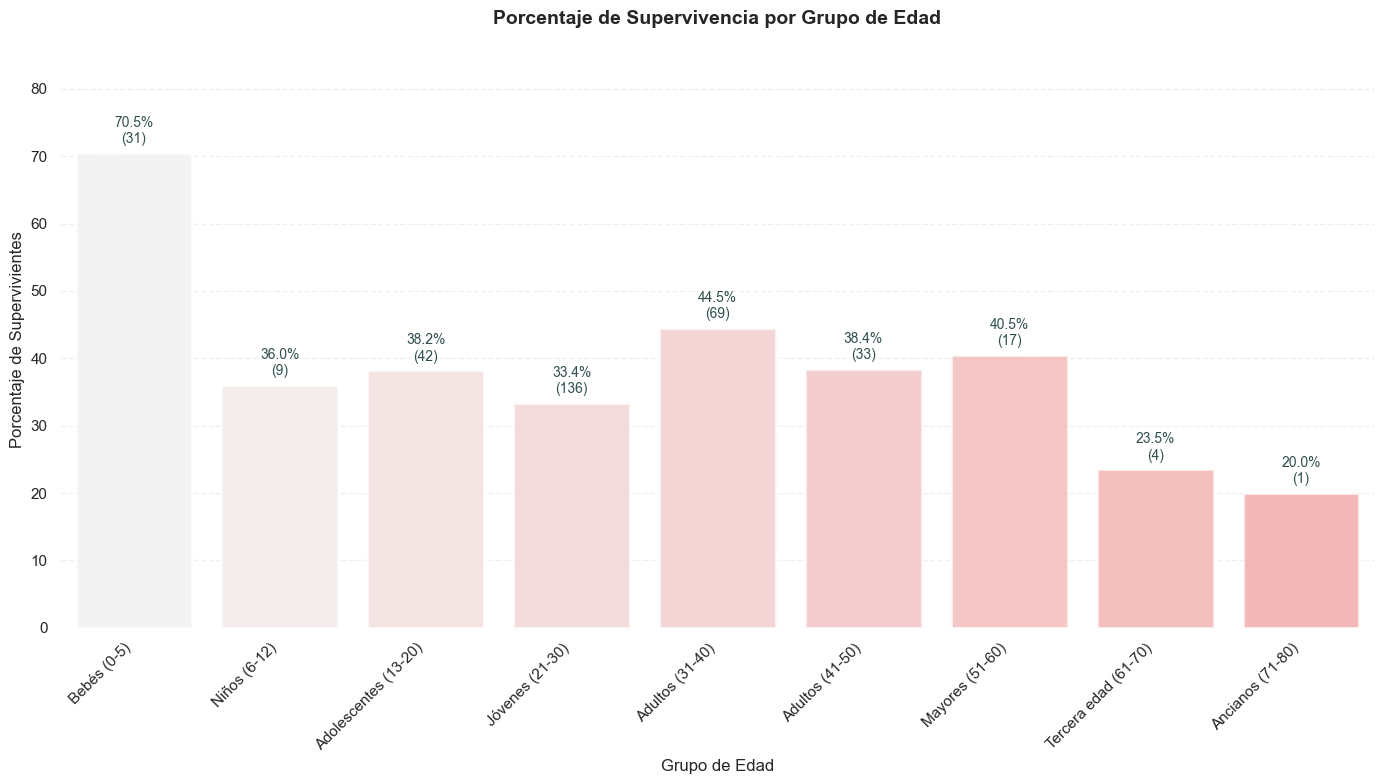

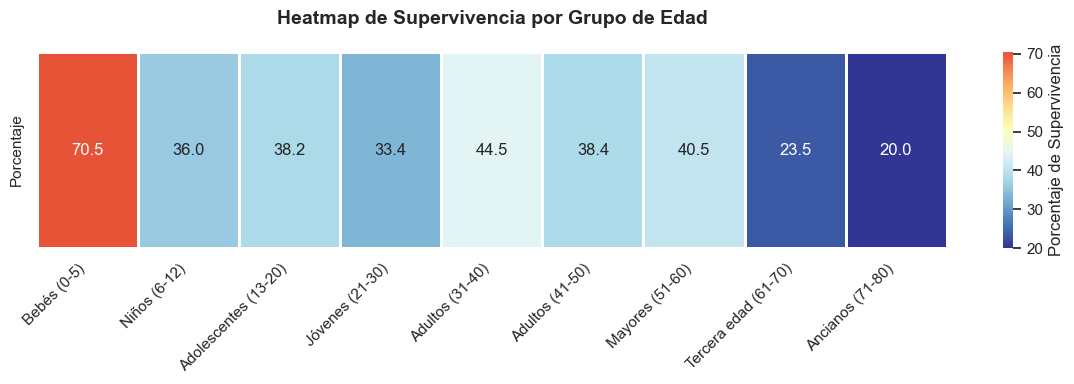

In [70]:
# Definir el orden de los grupos de edad
orden_grupos = [
    'Bebés (0-5)',
    'Niños (6-12)',
    'Adolescentes (13-20)',
    'Jóvenes (21-30)',
    'Adultos (31-40)',
    'Adultos (41-50)',
    'Mayores (51-60)',
    'Tercera edad (61-70)',
    'Ancianos (71-80)'
]

# Reordenar el DataFrame según el orden definido
stats_por_edad = stats_por_edad.reindex(orden_grupos)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Crear el gráfico de barras
ax = sns.barplot(data=stats_por_edad.reset_index(), 
                 x='RangoEdad', 
                 y='Porcentaje',
                 palette=sns.light_palette("#FF9999", n_colors=len(orden_grupos)),
                 edgecolor='white',
                 linewidth=2)

plt.title('Porcentaje de Supervivencia por Grupo de Edad', 
         fontsize=14, 
         fontweight='bold', 
         pad=20)
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Porcentaje de Supervivientes', fontsize=12)

plt.xticks(rotation=45, ha='right')

# Agregar porcentajes y número de sobrevivientes sobre las barras
for i, v in enumerate(stats_por_edad['Porcentaje']):
    sobrevivientes = stats_por_edad['Sobrevivientes'].iloc[i]
    ax.text(i, v + 1, f'{v:.1f}%\n({sobrevivientes})', 
            ha='center', 
            va='bottom', 
            fontsize=10,
            color='darkslategray')

plt.ylim(0, max(stats_por_edad['Porcentaje']) + 15)

for i, bar in enumerate(ax.patches):
    bar.set_alpha(0.8)
    
sns.despine(left=True, bottom=True)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Crear heatmap
plt.figure(figsize=(12, 4))
heatmap_data = stats_por_edad[['Porcentaje']].T
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.1f',
            cmap='RdYlBu_r',
            cbar_kws={'label': 'Porcentaje de Supervivencia'},
            linewidths=2,
            center=50)
plt.title('Heatmap de Supervivencia por Grupo de Edad', 
         fontsize=14, 
         fontweight='bold', 
         pad=20)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### % de supervencia entre hombres, mujeres y ninos por clase

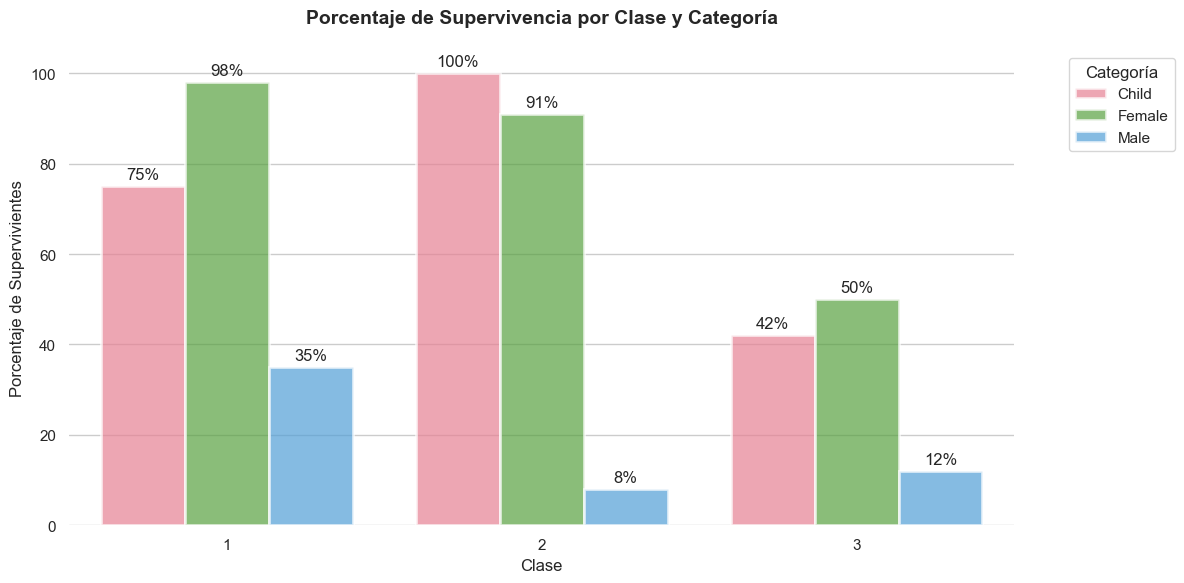

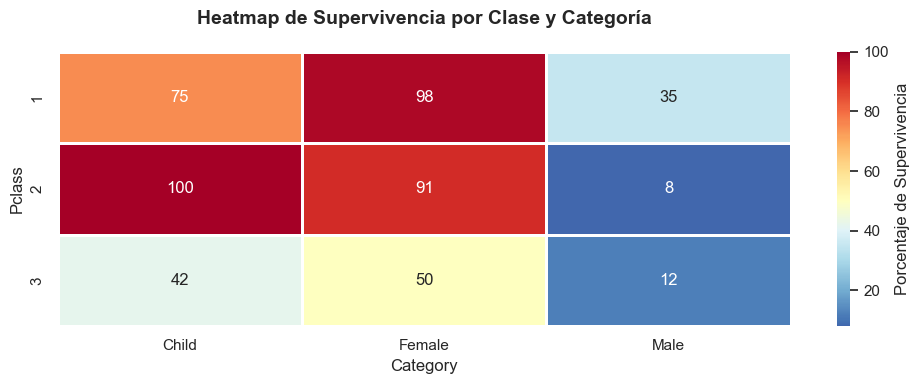

In [71]:
# Crear el gráfico principal
plt.figure(figsize=(12, 6))

# Crear el gráfico de barras agrupadas
ax = sns.barplot(
    data=supervivencia_formateada.reset_index().melt(id_vars='Pclass'),
    x='Pclass', y='value', hue='Category',
    palette='husl',
    alpha=0.7,
    edgecolor='white',
    linewidth=2
)

# Personalizar el gráfico
plt.title('Porcentaje de Supervivencia por Clase y Categoría', 
         fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Porcentaje de Supervivientes', fontsize=12)

# Añadir los valores sobre las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%d%%', padding=3)

# Personalizar la leyenda
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Crear heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(supervivencia_formateada, 
            annot=True, 
            fmt='d',
            cmap='RdYlBu_r',
            center=50,
            cbar_kws={'label': 'Porcentaje de Supervivencia'},
            linewidths=1)

plt.title('Heatmap de Supervivencia por Clase y Categoría', 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### supervivientes por sexo

In [1]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Remove plt.style.use line since we'll use seaborn's styling
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8')  # Using a valid style name
colors = ['#7CC6FE', '#FF9999']

# First subplot: Absolute numbers
sns.barplot(data=pd.melt(stats_por_sexo.reset_index(), 
                        id_vars=['Sex'], 
                        value_vars=['Sobrevivientes', 'Fallecidos']),
            x='Sex', y='value', hue='variable',
            palette=colors,
            alpha=0.8,
            ax=ax1)

# Add value labels on the bars
for container in ax1.containers:
    ax1.bar_label(container, padding=3)

ax1.set_title('Número de Sobrevivientes y Fallecidos por Sexo', 
              pad=15, fontsize=12, fontweight='bold')
ax1.set_xlabel('Sexo', fontsize=10)
ax1.set_ylabel('Número de Pasajeros', fontsize=10)
ax1.legend(title='', frameon=True, fancybox=True, shadow=True)

# Second subplot: Percentages
bars = sns.barplot(data=stats_por_sexo.reset_index(), 
                  x='Sex', y='Porcentaje Supervivencia',
                  palette=['#A8E6CF'],
                  alpha=0.8,
                  ax=ax2)

# Add percentage labels on bars
for i, v in enumerate(stats_por_sexo['Porcentaje Supervivencia']):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

ax2.set_title('Porcentaje de Supervivencia por Sexo', 
              pad=15, fontsize=12, fontweight='bold')
ax2.set_xlabel('Sexo', fontsize=10)
ax2.set_ylabel('Porcentaje de Supervivencia', fontsize=10)
ax2.set_ylim(0, 100)

# Add style elements
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_alpha(0.5)

plt.tight_layout()

  


NameError: name 'plt' is not defined

### survived 

In [ ]:
# calculate the average fare for each class
average_fare_per_class = df.groupby('Pclass')['Fare'].mean()
print(average_fare_per_class)

NameError: name 'df' is not defined